# LangGraph Streaming 활용
- 랭글래프가 실행되는 과정을 스트리밍으로 확인하는 방법

In [13]:
from dotenv import load_dotenv

load_dotenv()

OPENAI_LLM_MODEL = 'gpt-4.1-mini'

## 기본 그래프 생성

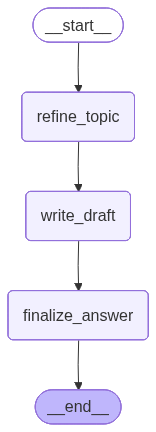

In [9]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.config import get_stream_writer

class State(TypedDict,total=False):
    topic:str               # 사용자가 입력한 원본 주제
    refined_topic:str       # 첫 번째 노드에서 구체화한 주제
    draft:str               # 두 번째 노드에서 생성한 초안
    final_answer:str        # 마지막 노드에서 정리한 최종 결과

def refine_topic(state:State):
    """사용자의 입력 주제를 수업 예제에 맞게 조금 더 구체화 한다."""
    writer = get_stream_writer()
    writer({'status':'입력주제를 구체화하는 중'})
    
    topic = state['topic']
    return {'refined_topic':f'{topic}을 처음 배우는 수강생에게 설명하기'}

def write_draft(state:State):
    """구체화된 주제를 바탕으로 간단한 초안을 만든다."""
    writer = get_stream_writer()
    writer({'status':'가단한 초안 마드는 중'})
    
    refined_topic = state['refined_topic']
    return {'draft':f'{refined_topic} 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}

def finalize_answer(state:State):
    """초안을 최종 답변 형태로 만든다."""
    writer = get_stream_writer()
    writer({'status':'최종 답변 생성 중'})

    draft = state['draft']
    return {'final_answer':f'초안 정리 : {draft}'}

builder = StateGraph(State)
builder.add_node("refine_topic",refine_topic)
builder.add_node("write_draft",write_draft)
builder.add_node("finalize_answer",finalize_answer)

builder.add_edge(START,'refine_topic')
builder.add_edge('refine_topic','write_draft')
builder.add_edge('write_draft','finalize_answer')
builder.add_edge('finalize_answer',END)

graph = builder.compile()
graph


## invoke()로 죄종 결과 확인하기

In [3]:
result = graph.invoke({'topic':"LangGraph Streaming"})
result

{'topic': 'LangGraph Streaming',
 'refined_topic': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기',
 'draft': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.',
 'final_answer': '초안 정리 : LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}

## stream_mode="updates"로 노드별 변경분 확인하기

In [4]:
stream_input = {'topic':"LangGraph Streaming"}

for chunk in graph.stream(stream_input,stream_mode='updates'):
    print('-'*80)
    print(chunk)

--------------------------------------------------------------------------------
{'refine_topic': {'refined_topic': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기'}}
--------------------------------------------------------------------------------
{'write_draft': {'draft': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}}
--------------------------------------------------------------------------------
{'finalize_answer': {'final_answer': '초안 정리 : LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}}


In [5]:
for chunk in graph.stream(
    stream_input,
    stream_mode='updates',
    version='v2'
    ):
        # chunk가 type, ns, data를 가진 구조로 일관성 있게 반환
    if chunk['type'] == 'updates':
        print('-'*80)
        print('stream type :',chunk['type'])
        print('namespace :',chunk['ns'])
        print('data :',chunk['data'])
        

--------------------------------------------------------------------------------
stream type : updates
namespace : ()
data : {'refine_topic': {'refined_topic': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기'}}
--------------------------------------------------------------------------------
stream type : updates
namespace : ()
data : {'write_draft': {'draft': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}}
--------------------------------------------------------------------------------
stream type : updates
namespace : ()
data : {'finalize_answer': {'final_answer': '초안 정리 : LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}}


## stream_mode='values'로 전체 state 확인하기

In [ ]:
for chunk in graph.stream(
    stream_input,
    stream_mode='values',
    version='v2'
    ):
        # chunk가 type, ns, data를 가진 구조로 일관성 있게 반환
    if chunk['type'] == 'values':
        print('-'*80)
        print('data :',chunk['data'])

--------------------------------------------------------------------------------
data : {'topic': 'LangGraph Streaming'}
--------------------------------------------------------------------------------
data : {'topic': 'LangGraph Streaming', 'refined_topic': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기'}
--------------------------------------------------------------------------------
data : {'topic': 'LangGraph Streaming', 'refined_topic': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기', 'draft': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}
--------------------------------------------------------------------------------
data : {'topic': 'LangGraph Streaming', 'refined_topic': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기', 'draft': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.', 'final_answer': '초안 정리 : LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}


## stream_mode = 'custom'으로 노드 내부사항 출력하기
- 'get_stream_writer'를 활용하면 노드가 반복하는 State 외에도 노드 내부의 

In [10]:
for chunk in graph.stream(
    stream_input,
    stream_mode='custom',
    version='v2'
    ):
        # chunk가 type, ns, data를 가진 구조로 일관성 있게 반환
    if chunk['type'] == 'custom':
        print('-'*80)
        print('data :',chunk['data'])

--------------------------------------------------------------------------------
data : {'status': '입력주제를 구체화하는 중'}
--------------------------------------------------------------------------------
data : {'status': '가단한 초안 마드는 중'}
--------------------------------------------------------------------------------
data : {'status': '최종 답변 생성 중'}


## 여러 steam mode 사용하기

In [11]:
for chunk in graph.stream(
    stream_input,
    stream_mode=['custom','updates'],
    version='v2'
    ):
        # chunk가 type, ns, data를 가진 구조로 일관성 있게 반환
    if chunk['type'] == 'custom':
        print('-'*80)
        print('custom data :',chunk['data'])

    if chunk['type'] == 'updates':
        print('-'*80)
        print('updates data :',chunk['data'])

--------------------------------------------------------------------------------
custom data : {'status': '입력주제를 구체화하는 중'}
--------------------------------------------------------------------------------
updates data : {'refine_topic': {'refined_topic': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기'}}
--------------------------------------------------------------------------------
custom data : {'status': '가단한 초안 마드는 중'}
--------------------------------------------------------------------------------
updates data : {'write_draft': {'draft': 'LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}}
--------------------------------------------------------------------------------
custom data : {'status': '최종 답변 생성 중'}
--------------------------------------------------------------------------------
updates data : {'finalize_answer': {'final_answer': '초안 정리 : LangGraph Streaming을 처음 배우는 수강생에게 설명하기 위해서는 먼저 핵심 용어를 정의하고 작은 예제로 실행 흐름을 확인하는 것이 좋다.'}}


## LLM 토큰 스트리밍

In [14]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=OPENAI_LLM_MODEL,
    temperature=0,
    streaming=True
)

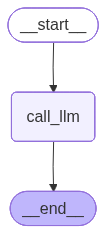

In [16]:
from langchain_core.messages import HumanMessage, SystemMessage

class LLMState(TypedDict, total=False):
    topic:str
    answer:str

def call_LLM(state:LLMState):
    """LLM을  호출해 주어진 주제에 대한 짧은 설명을 생성한다."""
    response = llm.invoke(
        [
            SystemMessage(content='초급 개발자에게 설명하듯이 간결하게 답변하세요.'),
            HumanMessage(content=f'{state['topic']}를 한 문단으로 설명해줘.')
        ]
    )
    return {'answer':response.content}

llm_builder = StateGraph(LLMState)
llm_builder.add_node('call_llm',call_LLM)
llm_builder.add_edge(START,'call_llm')
llm_builder.add_edge('call_llm',END)

llm_graph = llm_builder.compile()
llm_graph

## stram_mode='messages' 사용하기

In [18]:
for chunk in llm_graph.stream(
    {'topic':'LangGraph의 stream_mode messages'},
    stream_mode='messages',
    version= 'v2'
):
    if chunk['type'] == 'messages':
        message_chunk, metadata = chunk['data']

        if message_chunk.content:
            print(message_chunk.content,end='',flush=True)

LangGraph의 stream_mode messages는 실시간으로 데이터나 결과를 단계별로 받아볼 수 있게 해주는 기능입니다. 즉, 전체 작업이 끝날 때까지 기다리지 않고, 처리되는 중간중간의 메시지를 순차적으로 스트리밍 방식으로 전달해 줍니다. 이를 통해 사용자는 진행 상황을 바로 확인하고 빠르게 반응할 수 있습니다.

In [19]:
for chunk in llm_graph.stream(
    {'topic':'LangGraph의 stream_mode messages'},
    stream_mode=['messages','updates'],
    version= 'v2'
):
    if chunk['type'] == 'messages':
        message_chunk, metadata = chunk['data']

        if message_chunk.content:
            print(message_chunk.content,end='',flush=True)
    
    elif chunk['type'] == 'updates':
        print('\n\n[State update]')
        print(chunk['data'])

LangGraph의 stream_mode messages는 실시간으로 데이터나 결과를 단계별로 받아볼 수 있게 해주는 기능입니다. 즉, 전체 작업이 끝날 때까지 기다리지 않고, 처리되는 중간중간의 메시지를 순차적으로 스트리밍 방식으로 전달해 줍니다. 이를 통해 사용자는 진행 상황을 바로 확인하고 빠르게 반응할 수 있습니다.

[State update]
{'call_llm': {'answer': 'LangGraph의 stream_mode messages는 실시간으로 데이터나 결과를 단계별로 받아볼 수 있게 해주는 기능입니다. 즉, 전체 작업이 끝날 때까지 기다리지 않고, 처리되는 중간중간의 메시지를 순차적으로 스트리밍 방식으로 전달해 줍니다. 이를 통해 사용자는 진행 상황을 바로 확인하고 빠르게 반응할 수 있습니다.'}}
